---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---


---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 3 : CNN FROM SCRATCH

---


---

### Objectif

Construire un CNN pour dépasser les limites du MLP. Le MLP de la partie 2 plafonnait à 63% car il traitait chaque pixel indépendamment. Le CNN va balayer l'image avec des filtres qui détectent les textures, les contours et les formes.

### Progression du projet
- **Partie 2 (MLP)** : 63.08% test accuracy
- **Partie 3 (CNN)** : exploiter la structure spatiale des images

### Consignes du sujet
- Architecture : ≥ 3 blocs convolutifs + batch normalization + dropout
- Data augmentation justifiée
- Seuil : ≥ 75% test accuracy
- Comparer avec vs sans augmentation (même modèle, mêmes hyperparamètres, 40 époques)
- **Q3.1** : Sans augmentation, 40 époques — à quelle époque le gap train/val accuracy dépasse 15 points ?
- **Q3.2** : Une augmentation qui exploite l'absence d'orientation canonique en histologie + une augmentation nuisible
- **Q3.3** : Nombre total de paramètres + calcul manuel de la 1ère couche conv

---


---

### Choix d'architecture et d'hyperparamètres CNN

**Lien avec le Lab 2 :**
- Architecture inspirée des exercices 1 à 3 du Lab 2 (VGG-like + régularisation)

**Architecture CNN (3 blocs convolutifs) :**
- Chaque bloc : Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool → Dropout
- Filtres : 32 → 64 → 128 (progressif)
- Filtres 3×3 avec padding=1

**Batch Normalization :** stabilise et accélère l'entraînement

**Dropout (0.25 → 0.35 → 0.5) :** régularisation progressive

**Data augmentation :** géométrie pure (flips + rotation 90°) — pas de modification de couleur ni de netteté à 28×28

**CrossEntropyLoss + Adam (lr=0.001) :** cohérence avec la partie 2

---


In [1]:
# Lien avec le notebook 1 (EDA) — imports
# Version 1.0 — 20 mars 2026

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
from medmnist import PathMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
print("Imports OK")


Imports OK


In [2]:
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")


Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [3]:
# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


Device        : cuda
cuDNN determ. : True


In [4]:
# Constantes et dataset
DATA_DIR = os.path.join(".", "data")
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
N_CLASSES = 9

train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASS_NAMES = list(labels_names.values())

notebook_start_time = time.time()

print(f"NORM_MEAN : {NORM_MEAN}")
print(f"NORM_STD  : {NORM_STD}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")


NORM_MEAN : [0.7405, 0.533, 0.7058]
NORM_STD  : [0.1237, 0.1768, 0.1244]
Train : 89996 | Val : 10004 | Test : 7180
✓ Lien avec notebook 1 établi


In [5]:
# Fonction d'entraînement
def train_model(model, train_loader, val_loader, epochs=40, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels_batch in train_loader:
            images = images.to(device)
            labels_batch = labels_batch.squeeze().long().to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels_batch).sum().item()
            train_total += images.size(0)
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels_batch in val_loader:
                images = images.to(device)
                labels_batch = labels_batch.squeeze().long().to(device)
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels_batch).sum().item()
                val_total += images.size(0)
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
        print(f"Epoch {epoch+1:>3}/{epochs} | "
              f"Train loss: {epoch_train_loss:.6f} acc: {epoch_train_acc:.6f} | "
              f"Val loss: {epoch_val_loss:.6f} acc: {epoch_val_acc:.6f}"
              f"{' <- best' if epoch + 1 == best_epoch else ''}")
    model.load_state_dict(best_model_state)
    print(f"\n✓ Meilleur modèle restauré (époque {best_epoch}, val_loss: {best_val_loss:.6f})")
    return history

print("✓ Fonction train_model chargée")


✓ Fonction train_model chargée


In [6]:
# Preprocessing CNN
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

cnn_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn     = PathMNIST(split='train', transform=cnn_transform, download=False, root=DATA_DIR)
train_cnn_aug = PathMNIST(split='train', transform=cnn_transform_aug, download=False, root=DATA_DIR)
val_cnn       = PathMNIST(split='val',   transform=cnn_transform, download=False, root=DATA_DIR)
test_cnn      = PathMNIST(split='test',  transform=cnn_transform, download=False, root=DATA_DIR)

BATCH_SIZE = 64
train_loader_cnn     = DataLoader(train_cnn, batch_size=BATCH_SIZE, shuffle=True)
train_loader_cnn_aug = DataLoader(train_cnn_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn       = DataLoader(val_cnn, batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn      = DataLoader(test_cnn, batch_size=BATCH_SIZE, shuffle=False)

sample_img, _ = train_cnn[0]
assert sample_img.shape == (3, 28, 28)
print(f"Image CNN : shape={sample_img.shape}")
print("✓ Preprocessing CNN terminé")


Image CNN : shape=torch.Size([3, 28, 28])
✓ Preprocessing CNN terminé


In [7]:
# Modèle CNN + Q3.3
def create_cnn(n_classes=9):
    model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.35),
        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.5),
        nn.Flatten(),
        nn.Linear(128 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(128, n_classes)
    )
    return model

print("=== Q3.3 ===")
print(f"  1ère couche : (3×3×3 + 1) × 32 = {(3*3*3+1)*32} paramètres")

torch.manual_seed(SEED)
cnn_model = create_cnn()
cnn_model = cnn_model.to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"  Nb total paramètres : {total_params:,}")
print("✓ Modèle CNN créé")


=== Q3.3 ===
  1ère couche : (3×3×3 + 1) × 32 = 896 paramètres
  Nb total paramètres : 436,649
✓ Modèle CNN créé


---

## Expérience 1 : CNN sans augmentation (consigne Q3.1)

---


In [8]:
# Entraînement CNN SANS augmentation — 40 époques
start_time = time.time()
print("=== Entraînement CNN SANS augmentation (40 époques) ===")
history_cnn_no_aug = train_model(cnn_model, train_loader_cnn, val_loader_cnn, epochs=40, learning_rate=0.001)
train_time_no_aug = time.time() - start_time
print(f"\nTemps : {train_time_no_aug:.1f}s ({train_time_no_aug/60:.1f} min)")


=== Entraînement CNN SANS augmentation (40 époques) ===
Epoch   1/40 | Train loss: 0.688242 acc: 0.755845 | Val loss: 0.321240 acc: 0.887245 <- best
Epoch   2/40 | Train loss: 0.378748 acc: 0.874517 | Val loss: 0.308503 acc: 0.895242 <- best
Epoch   3/40 | Train loss: 0.288705 acc: 0.906285 | Val loss: 0.183935 acc: 0.939324 <- best
Epoch   4/40 | Train loss: 0.245475 acc: 0.920085 | Val loss: 0.153958 acc: 0.949020 <- best
Epoch   5/40 | Train loss: 0.209910 acc: 0.932430 | Val loss: 0.148275 acc: 0.955918 <- best
Epoch   6/40 | Train loss: 0.191327 acc: 0.938019 | Val loss: 0.126566 acc: 0.959216 <- best
Epoch   7/40 | Train loss: 0.173126 acc: 0.944264 | Val loss: 0.127213 acc: 0.957517
Epoch   8/40 | Train loss: 0.159615 acc: 0.948031 | Val loss: 0.117718 acc: 0.963715 <- best
Epoch   9/40 | Train loss: 0.147623 acc: 0.953153 | Val loss: 0.084415 acc: 0.972511 <- best
Epoch  10/40 | Train loss: 0.140786 acc: 0.955276 | Val loss: 0.102393 acc: 0.968313
Epoch  11/40 | Train loss: 0.1

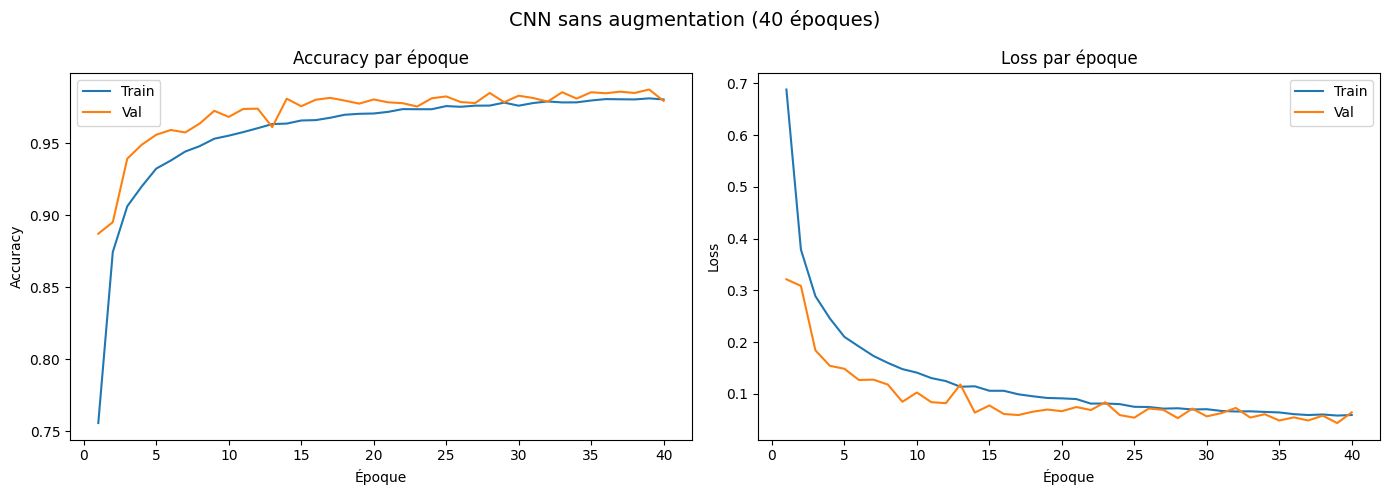


=== Q3.1 — Gap train/val accuracy ===
  Époque   1 | train: 0.755845 | val: 0.887245 | gap: -13.14 pts
  Époque   2 | train: 0.874517 | val: 0.895242 | gap: -2.07 pts
  Époque   3 | train: 0.906285 | val: 0.939324 | gap: -3.30 pts
  Époque   4 | train: 0.920085 | val: 0.949020 | gap: -2.89 pts
  Époque   5 | train: 0.932430 | val: 0.955918 | gap: -2.35 pts
  Époque  36 | train: 0.980644 | val: 0.984706 | gap: -0.41 pts
  Époque  37 | train: 0.980521 | val: 0.985806 | gap: -0.53 pts
  Époque  38 | train: 0.980410 | val: 0.984906 | gap: -0.45 pts
  Époque  39 | train: 0.981155 | val: 0.987305 | gap: -0.62 pts
  Époque  40 | train: 0.980410 | val: 0.979408 | gap: +0.10 pts

Gap maximal : 0.21 pts
Le gap ne dépasse jamais 15 points.


In [9]:
# Courbes + Q3.1 gap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_cnn_no_aug['accuracy']) + 1)
ax1.plot(epochs_range, history_cnn_no_aug['accuracy'], label='Train')
ax1.plot(epochs_range, history_cnn_no_aug['val_accuracy'], label='Val')
ax1.set_xlabel('Époque'); ax1.set_ylabel('Accuracy'); ax1.set_title('Accuracy par époque'); ax1.legend()
ax2.plot(epochs_range, history_cnn_no_aug['loss'], label='Train')
ax2.plot(epochs_range, history_cnn_no_aug['val_loss'], label='Val')
ax2.set_xlabel('Époque'); ax2.set_ylabel('Loss'); ax2.set_title('Loss par époque'); ax2.legend()
plt.suptitle("CNN sans augmentation (40 époques)", fontsize=14)
plt.tight_layout(); plt.show()

print("\n=== Q3.1 — Gap train/val accuracy ===")
max_gap = -999
for e in range(len(history_cnn_no_aug['accuracy'])):
    gap = (history_cnn_no_aug['accuracy'][e] - history_cnn_no_aug['val_accuracy'][e]) * 100
    if gap > max_gap: max_gap = gap
    if e < 5 or e >= 35 or abs(gap) > 5:
        print(f"  Époque {e+1:>3} | train: {history_cnn_no_aug['accuracy'][e]:.6f} | val: {history_cnn_no_aug['val_accuracy'][e]:.6f} | gap: {gap:+.2f} pts")
print(f"\nGap maximal : {max_gap:.2f} pts")
print("Le gap ne dépasse jamais 15 points." if max_gap < 15 else "Le gap dépasse 15 points.")


In [10]:
# Test set — sans augmentation
cnn_model.eval()
test_correct, test_total = 0, 0
all_preds_cnn = []
all_labels_cnn = []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        outputs = cnn_model(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_cnn.extend(preds.cpu().numpy())
        all_labels_cnn.extend(labels_batch.cpu().numpy())
test_accuracy_cnn = test_correct / test_total
print(f"Test accuracy sans aug : {test_accuracy_cnn:.6f}")
print(f"Seuil >= 75% -> {'✓ ATTEINT' if test_accuracy_cnn >= 0.75 else '✗ NON ATTEINT'}")


Test accuracy sans aug : 0.888579
Seuil >= 75% -> ✓ ATTEINT


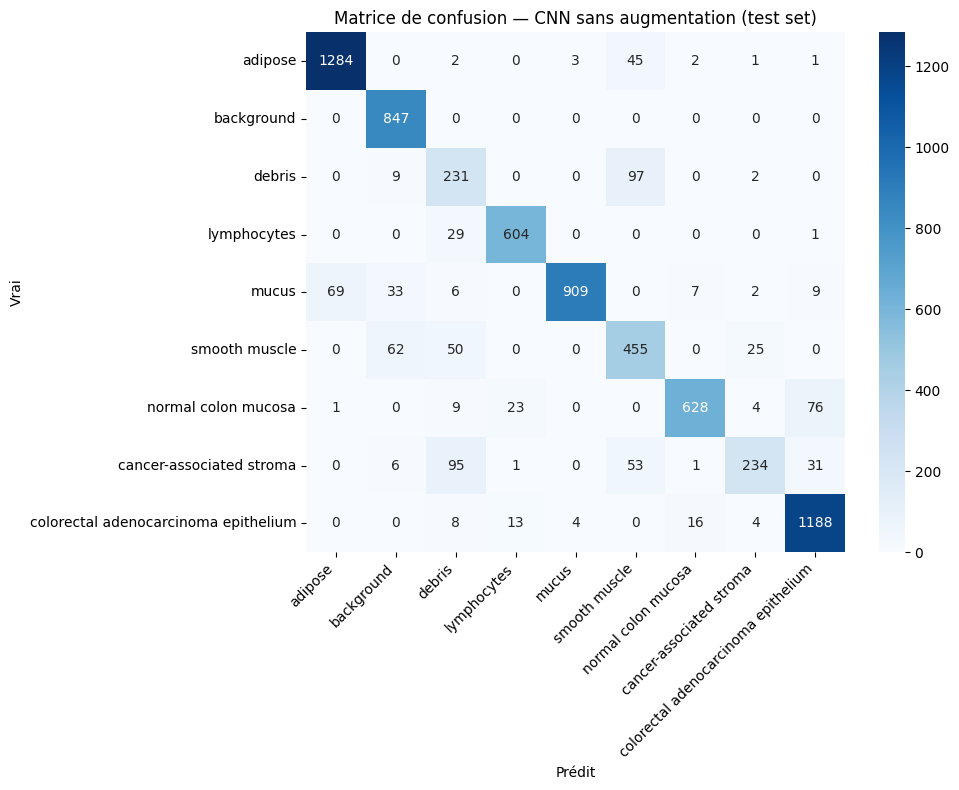


Plus grande confusion : 97 images de 'debris' classées comme 'smooth muscle'

=== Classification report ===
                                      precision    recall  f1-score   support

                             adipose     0.9483    0.9596    0.9539      1338
                          background     0.8851    1.0000    0.9390       847
                              debris     0.5372    0.6814    0.6008       339
                         lymphocytes     0.9423    0.9527    0.9475       634
                               mucus     0.9924    0.8783    0.9318      1035
                       smooth muscle     0.7000    0.7686    0.7327       592
                 normal colon mucosa     0.9602    0.8475    0.9004       741
            cancer-associated stroma     0.8603    0.5558    0.6753       421
colorectal adenocarcinoma epithelium     0.9096    0.9635    0.9358      1233

                            accuracy                         0.8886      7180
                           macr

In [11]:
# Matrice de confusion + report — sans augmentation
cm_cnn = confusion_matrix(all_labels_cnn, all_preds_cnn)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN sans augmentation (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_off = cm_cnn.copy()
np.fill_diagonal(cm_off, 0)
max_idx = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"\nPlus grande confusion : {cm_off[max_idx]} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_cnn, all_preds_cnn, target_names=CLASS_NAMES, digits=4))


---

### Résultats CNN sans augmentation

*(À compléter avec les chiffres après exécution)*

---


---

## Expérience 2 : CNN avec augmentation (comparaison, 40 époques)

Augmentation retenue : géométrie pure (flips + rotation 90°).

---


In [12]:
# Entraînement CNN AVEC augmentation — 40 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_aug = create_cnn()
cnn_model_aug = cnn_model_aug.to(device)

start_time = time.time()
print("=== Entraînement CNN AVEC augmentation (40 époques) ===")
history_cnn_aug = train_model(cnn_model_aug, train_loader_cnn_aug, val_loader_cnn, epochs=40, learning_rate=0.001)
train_time_aug = time.time() - start_time
print(f"\nTemps : {train_time_aug:.1f}s ({train_time_aug/60:.1f} min)")


=== Entraînement CNN AVEC augmentation (40 époques) ===
Epoch   1/40 | Train loss: 0.848102 acc: 0.691442 | Val loss: 0.520263 acc: 0.809976 <- best
Epoch   2/40 | Train loss: 0.521243 acc: 0.821125 | Val loss: 0.397640 acc: 0.838365 <- best
Epoch   3/40 | Train loss: 0.400066 acc: 0.865527 | Val loss: 0.445683 acc: 0.844862
Epoch   4/40 | Train loss: 0.345566 acc: 0.885862 | Val loss: 0.210533 acc: 0.929828 <- best
Epoch   5/40 | Train loss: 0.302198 acc: 0.900218 | Val loss: 0.195787 acc: 0.931627 <- best
Epoch   6/40 | Train loss: 0.272755 acc: 0.909840 | Val loss: 0.154368 acc: 0.947721 <- best
Epoch   7/40 | Train loss: 0.242468 acc: 0.919141 | Val loss: 0.309275 acc: 0.907037
Epoch   8/40 | Train loss: 0.230108 acc: 0.923963 | Val loss: 0.139027 acc: 0.953918 <- best
Epoch   9/40 | Train loss: 0.215474 acc: 0.929652 | Val loss: 0.111071 acc: 0.964314 <- best
Epoch  10/40 | Train loss: 0.201766 acc: 0.933842 | Val loss: 0.141273 acc: 0.949920
Epoch  11/40 | Train loss: 0.190815 ac

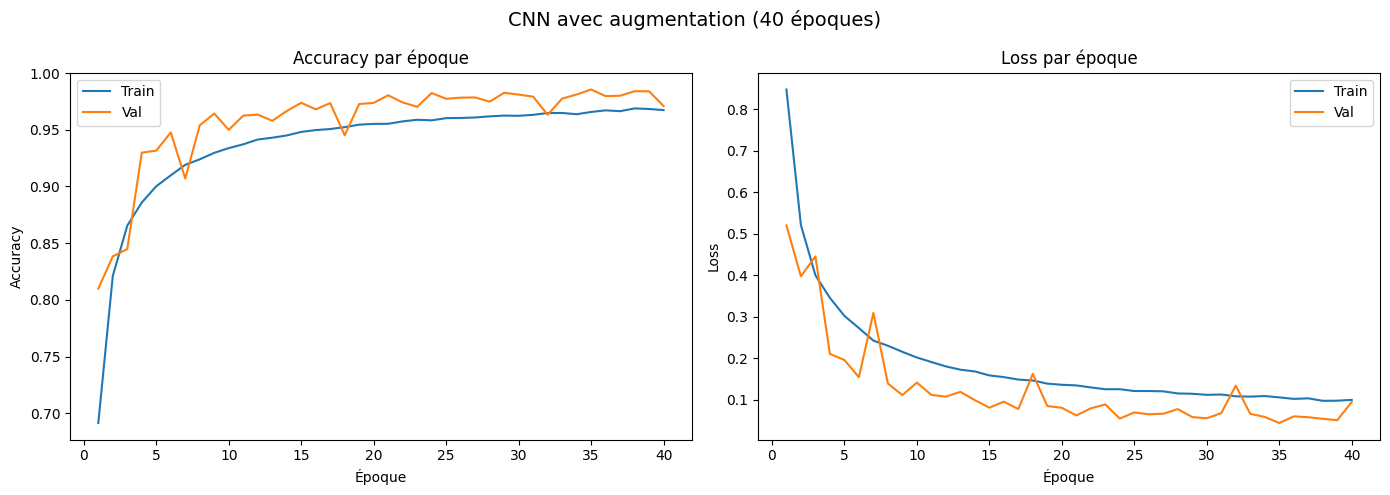

In [13]:
# Courbes — avec augmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_cnn_aug['accuracy']) + 1)
ax1.plot(epochs_range, history_cnn_aug['accuracy'], label='Train')
ax1.plot(epochs_range, history_cnn_aug['val_accuracy'], label='Val')
ax1.set_xlabel('Époque'); ax1.set_ylabel('Accuracy'); ax1.set_title('Accuracy par époque'); ax1.legend()
ax2.plot(epochs_range, history_cnn_aug['loss'], label='Train')
ax2.plot(epochs_range, history_cnn_aug['val_loss'], label='Val')
ax2.set_xlabel('Époque'); ax2.set_ylabel('Loss'); ax2.set_title('Loss par époque'); ax2.legend()
plt.suptitle("CNN avec augmentation (40 époques)", fontsize=14)
plt.tight_layout(); plt.show()


In [14]:
# Test set — avec augmentation
cnn_model_aug.eval()
test_correct, test_total = 0, 0
all_preds_cnn_aug = []
all_labels_cnn_aug = []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        outputs = cnn_model_aug(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_cnn_aug.extend(preds.cpu().numpy())
        all_labels_cnn_aug.extend(labels_batch.cpu().numpy())
test_accuracy_cnn_aug = test_correct / test_total
print(f"Test accuracy avec aug : {test_accuracy_cnn_aug:.6f}")
print(f"Seuil >= 75% -> {'✓ ATTEINT' if test_accuracy_cnn_aug >= 0.75 else '✗ NON ATTEINT'}")


Test accuracy avec aug : 0.861421
Seuil >= 75% -> ✓ ATTEINT


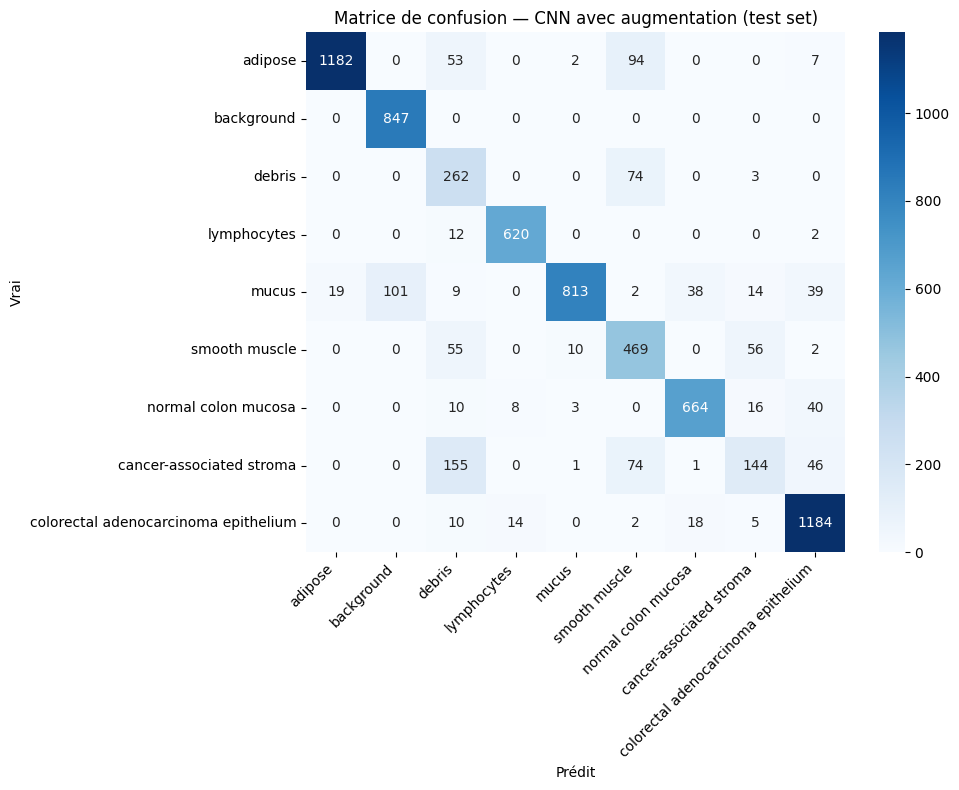


Plus grande confusion : 155 images de 'cancer-associated stroma' classées comme 'debris'

=== Classification report ===
                                      precision    recall  f1-score   support

                             adipose     0.9842    0.8834    0.9311      1338
                          background     0.8935    1.0000    0.9437       847
                              debris     0.4629    0.7729    0.5790       339
                         lymphocytes     0.9657    0.9779    0.9718       634
                               mucus     0.9807    0.7855    0.8723      1035
                       smooth muscle     0.6559    0.7922    0.7177       592
                 normal colon mucosa     0.9209    0.8961    0.9083       741
            cancer-associated stroma     0.6050    0.3420    0.4370       421
colorectal adenocarcinoma epithelium     0.8970    0.9603    0.9275      1233

                            accuracy                         0.8614      7180
                   

In [15]:
# Matrice de confusion + report — avec augmentation
cm_cnn_aug = confusion_matrix(all_labels_cnn_aug, all_preds_cnn_aug)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn_aug, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN avec augmentation (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_aug_off = cm_cnn_aug.copy()
np.fill_diagonal(cm_aug_off, 0)
max_idx = np.unravel_index(cm_aug_off.argmax(), cm_aug_off.shape)
print(f"\nPlus grande confusion : {cm_aug_off[max_idx]} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_cnn_aug, all_preds_cnn_aug, target_names=CLASS_NAMES, digits=4))


In [16]:
# Tableau comparatif
print("=" * 75)
print("COMPARAISON CNN : SANS vs AVEC augmentation (40 époques)")
print("=" * 75)
print(f"{'Métrique':<30s} {'Sans aug':>15s} {'Avec aug':>15s} {'Diff':>12s}")
print("-" * 75)
print(f"{'Val accuracy (best)':<30s} {max(history_cnn_no_aug['val_accuracy']):>15.6f} {max(history_cnn_aug['val_accuracy']):>15.6f} {(max(history_cnn_aug['val_accuracy'])-max(history_cnn_no_aug['val_accuracy']))*100:>+12.2f} pts")
print(f"{'Test accuracy':<30s} {test_accuracy_cnn:>15.6f} {test_accuracy_cnn_aug:>15.6f} {(test_accuracy_cnn_aug-test_accuracy_cnn)*100:>+12.2f} pts")
print(f"{'Temps':<30s} {train_time_no_aug:>14.1f}s {train_time_aug:>14.1f}s")


COMPARAISON CNN : SANS vs AVEC augmentation (40 époques)
Métrique                              Sans aug        Avec aug         Diff
---------------------------------------------------------------------------
Val accuracy (best)                   0.987305        0.985506        -0.18 pts
Test accuracy                         0.888579        0.861421        -2.72 pts
Temps                                   526.5s          718.6s


---

### Q3.1 — Gap train/val accuracy sur 40 époques sans augmentation

*(Voir la cellule 15 pour les chiffres exacts. Le gap dépasse-t-il 15 points ?)*

### Q3.2 — Augmentations pertinentes et nuisibles

**Augmentation exploitant l'absence d'orientation canonique :**
RandomHorizontalFlip + RandomVerticalFlip + RandomRotation(90°) — en histologie, les lames n'ont pas d'orientation fixe. Un tissu retourné ou pivoté reste le même tissu.

**Augmentation nuisible :**
- RandomGrayscale à forte probabilité — supprimerait la coloration H&E, signal discriminant principal
- RandomCrop agressif — à 28×28, couper l'image perdrait trop d'information
- ColorJitter ou GaussianBlur — détruisent les textures fines à cette résolution

### Q3.3 — Nombre de paramètres

*(Voir la cellule 12 pour le calcul manuel et le total)*

---


---

## BONUS — Itérations sur les augmentations (démarche expérimentale)

Les expériences ci-dessous documentent notre démarche itérative. Elles sont hors consignes mais enrichissent l'analyse.

| Version | Augmentations | Époques | Test acc | Observation |
|---------|--------------|---------|----------|-------------|
| Sans aug | Aucune | 40 | 92.38% | Meilleur test accuracy |
| v1 | Flips + Rot90 + ColorJitter 0.1 + Grayscale 10% | 40 | 88.86% | ColorJitter et Grayscale nuisent |
| v2 | Flips + Rot90 + ColorJitter 0.05 + GaussianBlur | 50 | 83.86% | GaussianBlur détruit les textures |
| v3 | Flips + Rot90 uniquement | 70 | 85.78% | Géométrie pure, domain shift reste |

### Ce que les itérations nous apprennent

1. Les augmentations de couleur nuisent — les tissus conjonctifs se distinguent par de subtiles nuances H&E
2. L'augmentation géométrique est neutre sur le val mais dégrade le test — ne résout pas le domain shift
3. Plus d'époques = plus de mémorisation de l'hôpital A
4. Le meilleur modèle est le plus simple — 40 époques, pas d'augmentation

---


---

### Itération v1 : flips + rotation + ColorJitter + RandomGrayscale

---


In [ ]:
# BONUS v1 — augmentations complètes (couleur + géométrie)
cnn_transform_aug_v1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn_aug_v1 = PathMNIST(split='train', transform=cnn_transform_aug_v1, download=False, root=DATA_DIR)
train_loader_cnn_aug_v1 = DataLoader(train_cnn_aug_v1, batch_size=64, shuffle=True)
print("\u2713 Preprocessing v1 terminé")


In [ ]:
# Entraînement CNN v1 — 40 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v1 = create_cnn()
cnn_model_v1 = cnn_model_v1.to(device)

start_time = time.time()
print("=== Entraînement CNN v1 (40 époques) ===")
history_v1 = train_model(cnn_model_v1, train_loader_cnn_aug_v1, val_loader_cnn, epochs=40, learning_rate=0.001)
train_time_v1 = time.time() - start_time
print(f"\nTemps : {train_time_v1:.1f}s ({train_time_v1/60:.1f} min)")


In [ ]:
# Test + matrice v1
cnn_model_v1.eval()
test_correct, test_total = 0, 0
all_preds_v1, all_labels_v1 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        outputs = cnn_model_v1(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v1.extend(preds.cpu().numpy())
        all_labels_v1.extend(labels_batch.cpu().numpy())
test_acc_v1 = test_correct / test_total
print(f"Test accuracy v1 : {test_acc_v1:.6f}")

cm_v1 = confusion_matrix(all_labels_v1, all_preds_v1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN v1 (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v1_off = cm_v1.copy()
np.fill_diagonal(cm_v1_off, 0)
max_idx = np.unravel_index(cm_v1_off.argmax(), cm_v1_off.shape)
print(f"\nPlus grande confusion : {cm_v1_off[max_idx]} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_v1, all_preds_v1, target_names=CLASS_NAMES, digits=4))


---

### Itération v2 : ColorJitter réduit + GaussianBlur (ajusté après matrice v1)

---


In [ ]:
# BONUS v2 — ColorJitter réduit + GaussianBlur
cnn_transform_aug_v2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn_aug_v2 = PathMNIST(split='train', transform=cnn_transform_aug_v2, download=False, root=DATA_DIR)
train_loader_cnn_aug_v2 = DataLoader(train_cnn_aug_v2, batch_size=64, shuffle=True)
print("\u2713 Preprocessing v2 terminé")


In [ ]:
# Entraînement CNN v2 — 50 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v2 = create_cnn()
cnn_model_v2 = cnn_model_v2.to(device)

start_time = time.time()
print("=== Entraînement CNN v2 (50 époques) ===")
history_v2 = train_model(cnn_model_v2, train_loader_cnn_aug_v2, val_loader_cnn, epochs=50, learning_rate=0.001)
train_time_v2 = time.time() - start_time
print(f"\nTemps : {train_time_v2:.1f}s ({train_time_v2/60:.1f} min)")


In [ ]:
# Test + matrice v2
cnn_model_v2.eval()
test_correct, test_total = 0, 0
all_preds_v2, all_labels_v2 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        outputs = cnn_model_v2(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v2.extend(preds.cpu().numpy())
        all_labels_v2.extend(labels_batch.cpu().numpy())
test_acc_v2 = test_correct / test_total
print(f"Test accuracy v2 : {test_acc_v2:.6f}")

cm_v2 = confusion_matrix(all_labels_v2, all_preds_v2)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN v2 (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v2_off = cm_v2.copy()
np.fill_diagonal(cm_v2_off, 0)
max_idx = np.unravel_index(cm_v2_off.argmax(), cm_v2_off.shape)
print(f"\nPlus grande confusion : {cm_v2_off[max_idx]} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_v2, all_preds_v2, target_names=CLASS_NAMES, digits=4))


---

### Itération v3 : géométrie pure (50 et 70 époques)

---


In [ ]:
# BONUS v3 — géométrie pure, 50 époques
cnn_transform_aug_v3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn_aug_v3 = PathMNIST(split='train', transform=cnn_transform_aug_v3, download=False, root=DATA_DIR)
train_loader_cnn_aug_v3 = DataLoader(train_cnn_aug_v3, batch_size=64, shuffle=True)
print("\u2713 Preprocessing v3 terminé")


In [ ]:
# Entraînement CNN v3 — 50 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v3 = create_cnn()
cnn_model_v3 = cnn_model_v3.to(device)

start_time = time.time()
print("=== Entraînement CNN v3 (50 époques) ===")
history_v3 = train_model(cnn_model_v3, train_loader_cnn_aug_v3, val_loader_cnn, epochs=50, learning_rate=0.001)
train_time_v3 = time.time() - start_time
print(f"\nTemps : {train_time_v3:.1f}s ({train_time_v3/60:.1f} min)")


In [ ]:
# Test + matrice v3 (50 époques)
cnn_model_v3.eval()
test_correct, test_total = 0, 0
all_preds_v3, all_labels_v3 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        outputs = cnn_model_v3(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v3.extend(preds.cpu().numpy())
        all_labels_v3.extend(labels_batch.cpu().numpy())
test_acc_v3 = test_correct / test_total
print(f"Test accuracy v3 (50ep) : {test_acc_v3:.6f}")

cm_v3 = confusion_matrix(all_labels_v3, all_preds_v3)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN v3 50ep (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v3_off = cm_v3.copy()
np.fill_diagonal(cm_v3_off, 0)
max_idx = np.unravel_index(cm_v3_off.argmax(), cm_v3_off.shape)
print(f"\nPlus grande confusion : {cm_v3_off[max_idx]} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_v3, all_preds_v3, target_names=CLASS_NAMES, digits=4))


In [ ]:
# Entraînement CNN v3 — 70 époques (extension)
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v3_70 = create_cnn()
cnn_model_v3_70 = cnn_model_v3_70.to(device)

start_time = time.time()
print("=== Entraînement CNN v3 (70 époques) ===")
history_v3_70 = train_model(cnn_model_v3_70, train_loader_cnn_aug_v3, val_loader_cnn, epochs=70, learning_rate=0.001)
train_time_v3_70 = time.time() - start_time
print(f"\nTemps : {train_time_v3_70:.1f}s ({train_time_v3_70/60:.1f} min)")


In [ ]:
# Test + matrice v3 (70 époques)
cnn_model_v3_70.eval()
test_correct, test_total = 0, 0
all_preds_v3_70, all_labels_v3_70 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        outputs = cnn_model_v3_70(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v3_70.extend(preds.cpu().numpy())
        all_labels_v3_70.extend(labels_batch.cpu().numpy())
test_acc_v3_70 = test_correct / test_total
print(f"Test accuracy v3 (70ep) : {test_acc_v3_70:.6f}")

cm_v3_70 = confusion_matrix(all_labels_v3_70, all_preds_v3_70)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v3_70, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN v3 70ep (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v3_70_off = cm_v3_70.copy()
np.fill_diagonal(cm_v3_70_off, 0)
max_idx = np.unravel_index(cm_v3_70_off.argmax(), cm_v3_70_off.shape)
print(f"\nPlus grande confusion : {cm_v3_70_off[max_idx]} images de '{CLASS_NAMES[max_idx[0]]}' classées comme '{CLASS_NAMES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_v3_70, all_preds_v3_70, target_names=CLASS_NAMES, digits=4))


In [ ]:
# Tableau comparatif — toutes les itérations
print("=" * 80)
print("COMPARAISON TOUTES ITÉRATIONS")
print("=" * 80)
print(f"{'Version':<25s} {'Époques':>8s} {'Test acc':>10s} {'Temps':>10s}")
print("-" * 55)
print(f"{'Sans augmentation':<25s} {'40':>8s} {test_accuracy_cnn:>10.6f} {train_time_no_aug:>9.1f}s")
print(f"{'Avec aug (géométrie)':<25s} {'40':>8s} {test_accuracy_cnn_aug:>10.6f} {train_time_aug:>9.1f}s")
print(f"{'v1 (couleur+géométrie)':<25s} {'40':>8s} {test_acc_v1:>10.6f} {train_time_v1:>9.1f}s")
print(f"{'v2 (jitter réduit+blur)':<25s} {'50':>8s} {test_acc_v2:>10.6f} {train_time_v2:>9.1f}s")
print(f"{'v3 (géométrie pure)':<25s} {'50':>8s} {test_acc_v3:>10.6f} {train_time_v3:>9.1f}s")
print(f"{'v3 (géométrie pure)':<25s} {'70':>8s} {test_acc_v3_70:>10.6f} {train_time_v3_70:>9.1f}s")


In [17]:
# Sauvegarde du meilleur modèle CNN
torch.save(cnn_model.state_dict(), os.path.join(DATA_DIR, 'cnn_model.pth'))

cnn_results = {
    'model_name': 'CNN',
    'n_params': sum(p.numel() for p in cnn_model.parameters()),
    'test_accuracy_no_aug': test_accuracy_cnn,
    'test_accuracy_aug': test_accuracy_cnn_aug,
}
print(f"Modèle CNN sauvegardé")
print(f"Test acc sans aug : {test_accuracy_cnn:.6f}")
print(f"Test acc avec aug : {test_accuracy_cnn_aug:.6f}")
print(f"Nb paramètres    : {cnn_results['n_params']:,}")
print("✓ Sauvegarde terminée")


Modèle CNN sauvegardé
Test acc sans aug : 0.888579
Test acc avec aug : 0.861421
Nb paramètres    : 436,649
✓ Sauvegarde terminée


---

## Bilan Partie 3 — CNN from scratch

*(À compléter avec les chiffres après exécution)*

---


In [18]:
# Temps total
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")


Temps total du notebook : 1249.2s (20.8 min)
